# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st
import statsmodels.api as sm

In [2]:
def fit_ols(x, y):
    """Fits OLS regression and returns model and predicted values."""
    X_const = sm.add_constant(x)
    model = sm.OLS(y, X_const).fit()
    y_pred = model.predict(X_const)
    return model, y_pred

def plot_scatter_with_line(x, y, y_pred, r2, title="Scatter with Regression", xlabel="X", ylabel="Y"):
    """Plots scatter plot and regression line with R^2."""
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, label="Data")
    plt.plot(x, y_pred, color='red', label=f"Regression line\n$R^2={r2:.2f}$")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

def scatter_with_regression(x, y, title="Scatter with Regression", xlabel="X", ylabel="Y"):
    model, y_pred = fit_ols(x, y)
    r2 = r2_score(y, y_pred)
    plot_scatter_with_line(x, y, y_pred, r2, title, xlabel, ylabel)
    return model
    
def scatter_with_regression_zoom(x, y, title="Scatter with Regression", 
                                 xlabel="X", ylabel="Y", zoom=(0,0)):
    """
    Fit OLS on full data, but optionally zoom in by removing extremes from plotting.
    zoom = (n_x, n_y) removes n_x extreme points from x and n_y from y (top or bottom)
    """
    # If x is a single-column DataFrame, convert to Series
    if isinstance(x, pd.DataFrame) and x.shape[1] == 1:
        x = x.iloc[:,0]
        
    # Fit full model
    model, y_pred = fit_ols(x, y)
    
    # Determine indices to keep
    idx_x = np.arange(len(x))
    idx_y = np.arange(len(y))
    
    if zoom[0] > 0:
        # Remove n_x most extreme x values (top or bottom)
        sorted_x_idx = np.argsort(x)
        idx_x = sorted_x_idx[zoom[0]:-zoom[0]] if zoom[0]*2 < len(x) else sorted_x_idx
    if zoom[1] > 0:
        # Remove n_y most extreme y values (top or bottom)
        sorted_y_idx = np.argsort(y)
        idx_y = sorted_y_idx[zoom[1]:-zoom[1]] if zoom[1]*2 < len(y) else sorted_y_idx
    
    # Intersection of indices to keep
    keep_idx = np.intersect1d(idx_x, idx_y)
    
    # Filter for plotting only
    x_plot = x.iloc[keep_idx] if isinstance(x, pd.Series) else x[keep_idx]
    y_plot = y.iloc[keep_idx] if isinstance(y, pd.Series) else y[keep_idx]
    y_pred_plot = y_pred[keep_idx]
    
    # Plot
    r2 = r2_score(y, y_pred)
    plot_scatter_with_line(x_plot, y_plot, y_pred_plot, r2, title=title, xlabel=xlabel, ylabel=ylabel)
    
    return model

def scatter_two_predictors_side_by_side_with_predictions(X, y, predictor1, predictor2):
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    
    for i, col in enumerate([predictor1, predictor2]):
        x = X[col]
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        y_pred = model.predict(X_const)
        r2 = r2_score(y, y_pred)
        
        # Plot scatter and regression line
        sorted_idx = x.argsort()
        x_sorted = x.iloc[sorted_idx]
        y_pred_sorted = y_pred.iloc[sorted_idx]
        axes[i].scatter(x, y, label="Data", alpha=0.6)
        axes[i].plot(x_sorted, y_pred_sorted, color='red', label=f"Regression line\n$R^2={r2:.2f}$")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Y")
        axes[i].set_title(f"{col} vs Y (full model regression)")
        axes[i].legend()
    
    # Plot predicted vs observed Y
    y_pred_full = sm.OLS(y, sm.add_constant(X)).fit().predict(sm.add_constant(X))
    axes[2].scatter(y, y_pred_full, color='green', alpha=0.6, label="Predicted vs Observed")
    axes[2].plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', label='Perfect prediction')
    axes[2].set_xlabel("Observed Y")
    axes[2].set_ylabel("Predicted Y")
    axes[2].set_title("Predicted vs Observed Y")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

def plot_residuals_vs_fitted(model, ax=None):
    residuals = model.resid
    fitted = model.fittedvalues
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(fitted, residuals, alpha=0.6)
    sns.regplot(x=fitted, y=residuals, lowess=True, ax=ax, line_kws={'color':'red'})
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')
    ax.text(0.95,0.05,'Random scatter ~ linearity OK\nFunnel shape ~ heteroscedasticity',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    ax.set_title('Residuals vs Fitted')
    return ax

def plot_scale_location(model, ax=None):
    residuals = model.resid
    fitted = model.fittedvalues
    sqrt_std_resid = np.sqrt(np.abs(residuals / np.std(residuals)))
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(fitted, sqrt_std_resid, alpha=0.6)
    sns.regplot(x=fitted, y=sqrt_std_resid, lowess=True, ax=ax, line_kws={'color':'red'})
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Sqrt(|Standardized Residuals|)')
    ax.set_title('Scale-Location')
    ax.text(0.95,0.05,'Horizontal ~ constant variance\nRising/falling ~ heteroscedasticity',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_qq(model, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    sm.qqplot(residuals, line='45', ax=ax)
    ax.set_title('Q-Q Plot')
    ax.text(0.95,0.05,'Points ~45° line → normal\nDeviations → non-normality',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_residual_autocorrelation(model, show_acf=True, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    if show_acf:
        sm.graphics.tsa.plot_acf(residuals, ax=ax)
        ax.set_title('Residual Autocorrelation')
        ax.text(0.95,0.05,'Spikes outside CI → dependence\nOtherwise → independent',
                transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    else:
        ax.scatter(np.arange(len(residuals)), residuals)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel('Observation')
        ax.set_ylabel('Residuals')
        ax.set_title('Residuals vs Observation')
        ax.text(0.95,0.05,'Random scatter → independent\nPatterns → autocorrelation',
                transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_residuals_histogram(model, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
    ax.set_title("Histogram of Residuals")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.text(0.95, 0.95, "Bell-shaped → normal\nSkew/multimodal → non-normal",
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            horizontalalignment='right', color='blue')

def plot_diagnostics_annotated(model, show_acf=True):
    fig, axs = plt.subplots(2, 3, figsize=(18,10))
    
    plot_residuals_vs_fitted(model, ax=axs[0,0])
    plot_scale_location(model, ax=axs[0,1])
    plot_residual_autocorrelation(model, ax=axs[0,2], show_acf=False)  # Residuals vs Observation

    plot_qq(model, ax=axs[1,0])
    plot_residuals_histogram(model, ax=axs[1,1])
    plot_residual_autocorrelation(model, ax=axs[1,2], show_acf=True)  # ACF
    plt.tight_layout()
    plt.show()

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
file_path = "prices_20250821-180122.parquet"
df = pd.read_parquet(file_path)
df.head()

,date,aapl,VCNIX
0,2025-03-28,217.90,20.83
1,2025-03-31,222.13,20.83
2,2025-04-01,223.19,21.00
3,2025-04-02,223.89,21.16
4,2025-04-03,203.19,20.01


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
X = df[['VCNIX']]
y = df['aapl']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=-0.7172  RMSE=14.193684


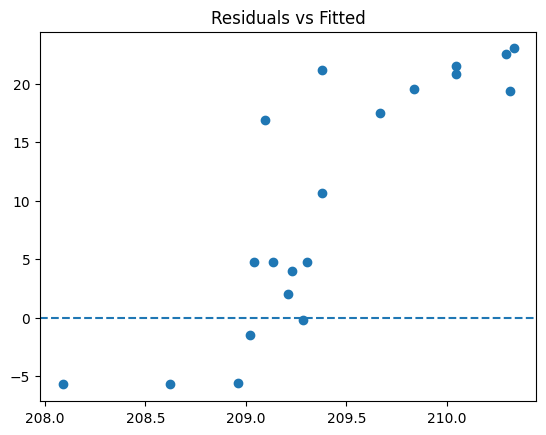

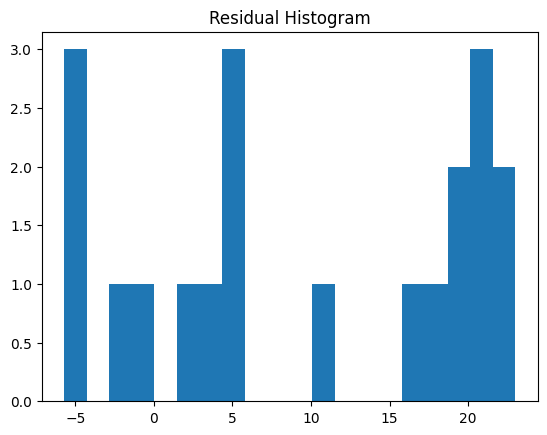

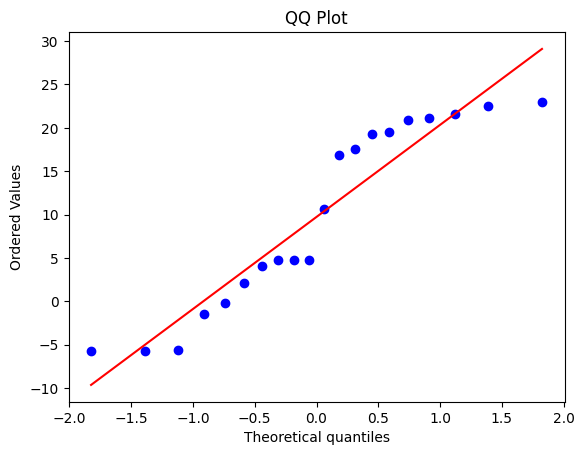

<Axes: title={'center': 'Residual Autocorrelation'}>

<Figure size 640x480 with 0 Axes>

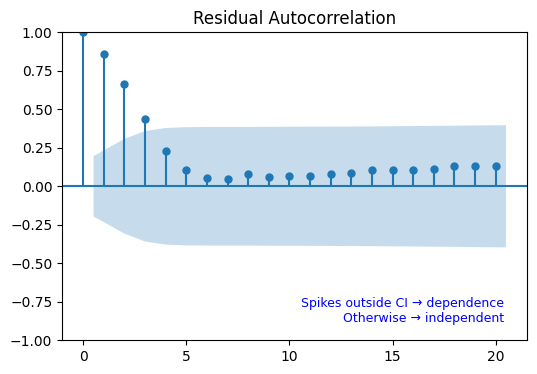

In [5]:
resid = y_test - y_pred
fitted = y_pred
model_ind = sm.OLS(y, sm.add_constant(X)).fit()
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()
plt.figure(); plot_residual_autocorrelation(model_ind, show_acf=True)

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [13]:
df['VCNIX_sq'] = df['VCNIX']**2
X2 = df[['VCNIX_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
#rmse_2 = mean_squared_error(y_test, y_pred2, squared=False)
mse = mean_squared_error(y_test, y_pred)
rmse_2 = np.sqrt(mse)
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=-1.7669  RMSE=14.193684


In [7]:
df['aapl_log'] = np.log(df['aapl'] - df['aapl'].min() + 1)
X3 = df[['VCNIX']]
y3 = df['aapl_log']
X3_train, X3_test = X3.iloc[:len(X_train)], X3.iloc[len(X_train):]
y3_train, y3_test = y3.iloc[:len(y_train)], y3.iloc[len(y_train):]
lr3 = LinearRegression().fit(X3_train, y3_train)
y3_pred = lr3.predict(X3_test)
r2_3 = r2_score(y3_test, y3_pred)
#rmse_2 = mean_squared_error(y_test, y_pred2, squared=False)
mse = mean_squared_error(y3_test, y3_pred)
rmse_3 = np.sqrt(mse)
print(f'With x^2   R²={r2_3:.4f}  RMSE={rmse_3:.6f}')

With x^2   R²=0.0367  RMSE=0.233226


## 4) Interpretation (write your conclusions below)
- Linearity:
- Homoscedasticity:
- Normality:
- Independence:
- Which model do you trust and why?:
- Next step you’d try:

In [18]:
# From the residuals vs fitted plot I can see that linearity is violated, homoscedasticity Violated.
# From QQ-plot, normality is OK.
# From ACF that I can see it is dependent.
# I would trust the log tansformation of AAPL,it could reduce the heteroscedasticity, remains an acceptable rmse and a reasonable r2.
# Next, I would aim to find some other variales to add into the regression.